In [3]:
## Notebook run usin huggingface_torch_gpu environment

In [65]:
from re import L
import torch
import librosa
import pickle
import numpy as np
from pathlib import Path
import IPython.display as ipd

%matplotlib inline
import matplotlib.pyplot as plt

## Use TTS generate audio from text for target excerpts



In [56]:
gen_path = Path('generated_experiment_stimuli/attn_epmnt_text_promps_v00/')
# make directories
audio_path = Path('generated_experiment_stimuli/attn_expmnt_audio_v00/')
# make directories
audio_path.mkdir(parents=True, exist_ok=True)


with open(gen_path / 'final_list_of_target_transcripts.pkl', 'rb') as f:
	transcripts_to_generate = pickle.load(f)

In [3]:
len(transcripts_to_generate)

488

#### Render examples using TTS models 

In [68]:
from scipy.fft import rfft, rfftfreq


def plot_power_spec(wav, axs, sr=16000, title=''):
    # get specturm of the audio
    ps = np.abs(rfft(wav))
    ps_to_db = 20*np.log10(ps/ps.max())
    freqs = rfftfreq(wav.size, 1/sr)
    idx = np.argsort(freqs)
    # axs.semilogx(freqs[idx], ps_to_db[idx], linewidth=0.5, alpha=0.9)
    axs.plot(freqs[idx], ps_to_db[idx], linewidth=0.5, alpha=0.9)
    axs.axis([0, 22000, -100, 5]) # 40 is lowest freq of 40Hz

    axs.set_ylabel('Power spectrum (dB)')
    axs.set_xlabel('Frequency (Hz)')
    axs.set_title(title)
    axs.axvline(16000, linewidth=0.5, color='k', linestyle='--')
    # axs.set_xscale('log')
    # axs.set_ylim(-100, 0)
    return None 

In [5]:
from transformers import pipeline
from datasets import load_dataset
import soundfile as sf

/om2/user/imgriff/conda_envs/huggingface_gpu_torch2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# see if gpu is available
torch.cuda.is_available()
# count gpus
torch.cuda.device_count()

1

In [7]:
eg_sentence = transcripts_to_generate['about'][0]

In [15]:
### Using microsoft speecht5_tts

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device=0)

# this is how they handle speaker selection - need to figure out how to change voices this way 
embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0).cuda()
# You can replace this embedding with your own as well.

speech = synthesiser(eg_sentence, forward_params={"speaker_embeddings": speaker_embedding})

# sf.write("speech.wav", speech["audio"], samplerate=speech["sampling_rate"])
print(speech['sampling_rate'])
ipd.Audio(speech['audio'], rate = speech['sampling_rate'])

16000


In [18]:
### Using meta MMS   https://huggingface.co/facebook/mms-tts-eng 

from transformers import VitsModel, AutoTokenizer
import torch

model = VitsModel.from_pretrained("facebook/mms-tts-eng").cuda()
tokenizer = AutoTokenizer.from_pretrained("facebook/mms-tts-eng")

inputs = tokenizer(eg_sentence, return_tensors="pt")

inputs = {name: tensor.cuda() for name, tensor in inputs.items()}

with torch.no_grad():
    output = model(**inputs).waveform

print(model.config.sampling_rate)
ipd.Audio(output.cpu().numpy(), rate=model.config.sampling_rate)

Some weights of the model checkpoint at facebook/mms-tts-eng were not used when initializing VitsModel: ['flow.flows.0.wavenet.in_layers.0.weight_g', 'flow.flows.0.wavenet.in_layers.0.weight_v', 'flow.flows.0.wavenet.in_layers.1.weight_g', 'flow.flows.0.wavenet.in_layers.1.weight_v', 'flow.flows.0.wavenet.in_layers.2.weight_g', 'flow.flows.0.wavenet.in_layers.2.weight_v', 'flow.flows.0.wavenet.in_layers.3.weight_g', 'flow.flows.0.wavenet.in_layers.3.weight_v', 'flow.flows.0.wavenet.res_skip_layers.0.weight_g', 'flow.flows.0.wavenet.res_skip_layers.0.weight_v', 'flow.flows.0.wavenet.res_skip_layers.1.weight_g', 'flow.flows.0.wavenet.res_skip_layers.1.weight_v', 'flow.flows.0.wavenet.res_skip_layers.2.weight_g', 'flow.flows.0.wavenet.res_skip_layers.2.weight_v', 'flow.flows.0.wavenet.res_skip_layers.3.weight_g', 'flow.flows.0.wavenet.res_skip_layers.3.weight_v', 'flow.flows.1.wavenet.in_layers.0.weight_g', 'flow.flows.1.wavenet.in_layers.0.weight_v', 'flow.flows.1.wavenet.in_layers.1.wei

16000


/om2/user/imgriff/conda_envs/huggingface_gpu_torch2/lib/python3.12/site-packages/torch/nn/modules/conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608847532/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,


In [29]:
from transformers import AutoProcessor, BarkModel


processor = AutoProcessor.from_pretrained("suno/bark", device_map='cuda')
model = BarkModel.from_pretrained("suno/bark", device_map ='cuda')


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.


24000


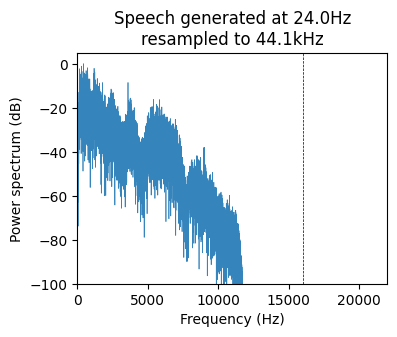

In [81]:

voice_preset = "v2/en_speaker_8"

inputs = processor(eg_sentence, voice_preset=voice_preset).to("cuda")

# push inputs to gpu. inputs is dict. sometimes values are also dicts. push those items to gpu as well

# for key, value in inputs.items():
# 	if isinstance(value, dict):
# 		inputs[key] = {k: v.cuda() for k, v in value.items()}
# 	else:
# 		inputs[key] = value.cuda()


audio_array = model.generate(**inputs)
audio_array = audio_array.cpu().numpy().squeeze()

sampling_rate = model.generation_config.sample_rate

## updample aduio to 44.1kHz and re-plot 

audio_array = librosa.resample(y=audio_array, orig_sr=sampling_rate, target_sr=44100)

print(sampling_rate)
ipd.display(ipd.Audio(audio_array, rate=44100))
fig, axs = plt.subplots(figsize=(4,3))

plot_power_spec(audio_array, axs, title=f'Speech generated at {sampling_rate/1000:.1f}Hz\nresampled to 44.1kHz', sr=44100)